# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 30 dias | Ventana salida: 1 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [22]:
VENTANA_ENTRADA = 30   # dias de entrada
VENTANA_SALIDA  = 1   # dias de salida (promedio)


In [23]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import construir_dense, construir_dense_v2, construir_dense_v3, construir_dense_v4, construir_dense_v5, construir_dense_v6, construir_recurrente, construir_conv1d, construir_mixto
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
CALLBACKS = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
]


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [24]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16160, 30, 23)  |  y: (16160, 23)
Train: (13816, 30, 23)  Val: (728, 30, 23)  Test: (1616, 30, 23)


## 1.2 Baselines

In [25]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.011530  0.009722  0.012909         0
BuyAndHold   0.011694  0.009199  0.012251         0


## 1.3 Modelo Dense (MLP)

In [26]:
# Entrenamiento de todas las variantes Dense, como en ent90_sal05.
def crear_callbacks_dense():
    return [
        EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    ]

dense_configs = [
    ('Dense', construir_dense),
    ('Dense_v2', construir_dense_v2),
    ('Dense_v3', construir_dense_v3),
    ('Dense_v4', construir_dense_v4),
    ('Dense_v5', construir_dense_v5),
    ('Dense_v6', construir_dense_v6),
]

modelos_dense = {}
historias_dense = {}

for i, (nombre, constructor) in enumerate(dense_configs, start=1):
    print(f'\nEntrenando {nombre} ({i}/{len(dense_configs)})')
    modelo = constructor(X_train_plano.shape[1], y_train.shape[1])
    modelo.summary()
    hist = modelo.fit(
        X_train_plano, y_train,
        validation_data=(X_val_plano, y_val),
        epochs=100,
        batch_size=64,
        callbacks=crear_callbacks_dense(),
        verbose=1,
    )
    modelos_dense[nombre] = modelo
    historias_dense[nombre] = hist
    globals()[f'modelo_dense_{i}'] = modelo
    globals()[f'hist_dense_{i}'] = hist

# Alias para compatibilidad con celdas antiguas.
modelo_dense = modelo_dense_1
hist_dense = hist_dense_1



Entrenando Dense (1/6)


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │        22,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,511 (138.71 KB)

 Trainable params: 35,511 (138.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0129 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0118 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0118 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 6/100
179/216 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 0.0118
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0117 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0117 - val_loss: 0.0094 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0116 - val_loss: 0.009

{'modelo': 'Dense', 'mae_train': 0.011371403265795376, 'mae_val': 0.009213440526893208, 'mae_test': 0.012348477727393, 'n_params': 212759}
{'modelo': 'Dense_v2', 'mae_train': 0.011607984942402243, 'mae_val': 0.009215143788601003, 'mae_test': 0.012252968297270463, 'n_params': 99543}
{'modelo': 'Dense_v3', 'mae_train': 0.011158376181378514, 'mae_val': 0.009203191773144026, 'mae_test': 0.01246054125188302, 'n_params': 527767}
{'modelo': 'Dense_v4', 'mae_train': 0.011677461414357104, 'mae_val': 0.009214461738062289, 'mae_test': 0.012259881685106052, 'n_params': 98199}
{'modelo': 'Dense_v5', 'mae_train': 0.011333554558840492, 'mae_val': 0.009449935349478815, 'mae_test': 0.012577391684560386, 'n_params': 182807}
{'modelo': 'Dense_v6', 'mae_train': 0.011507019396224897, 'mae_val': 0.00929430098865272, 'mae_test': 0.01238260601598556, 'n_params': 35511}


,modelo,mae_train,mae_val,mae_test,n_params
0,Dense_v3,0.011158,0.009203,0.012461,527767
1,Dense,0.011371,0.009213,0.012348,212759
2,Dense_v4,0.011677,0.009214,0.012260,98199
3,Dense_v2,0.011608,0.009215,0.012253,99543
4,Dense_v6,0.011507,0.009294,0.012383,35511
5,Dense_v5,0.011334,0.009450,0.012577,182807


Mejor Dense elegido:
{'modelo': 'Dense_v3', 'mae_train': 0.011158376181378514, 'mae_val': 0.009203191773144026, 'mae_test': 0.01246054125188302, 'n_params': 527767}


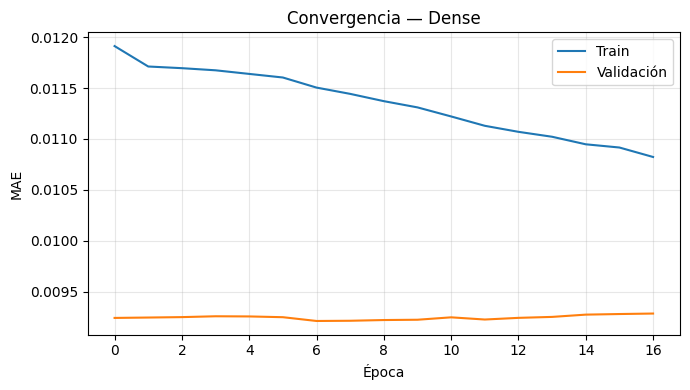

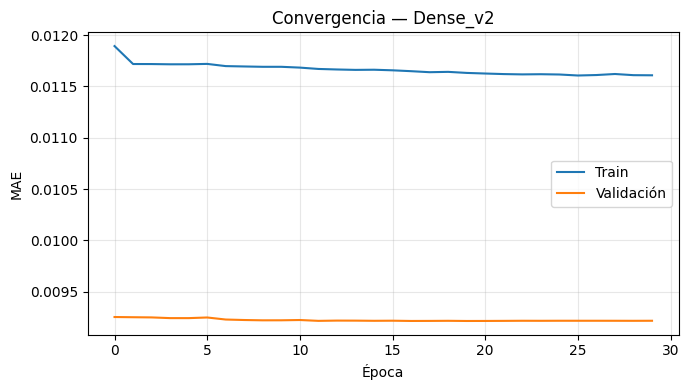

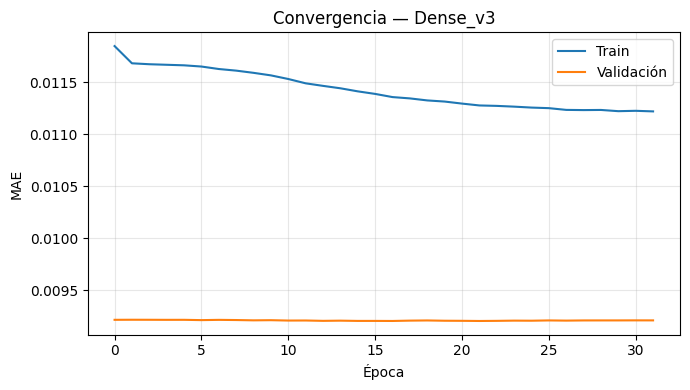

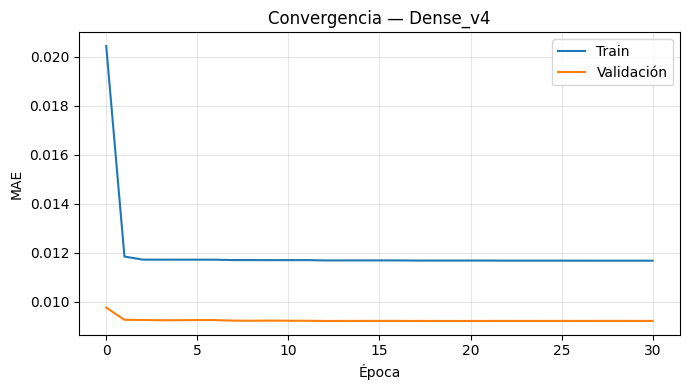

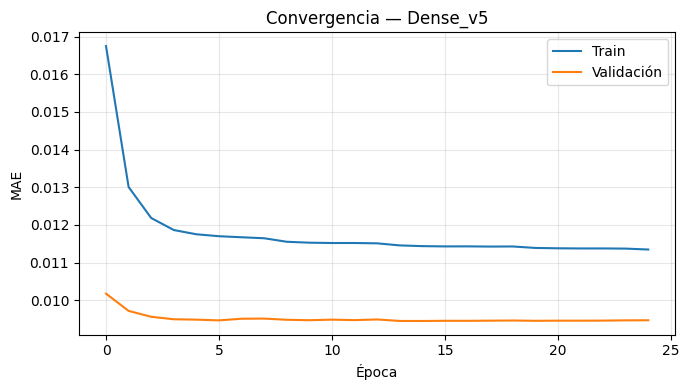

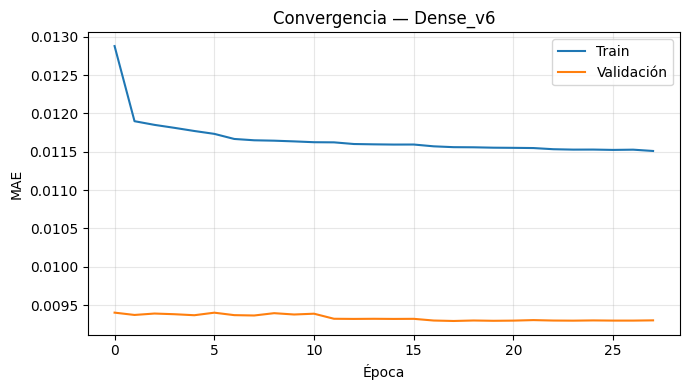

In [43]:
# Evaluacion y seleccion del mejor modelo Dense.
resultados_dense = []

for i, (nombre, _) in enumerate(dense_configs, start=1):
    hist = historias_dense[nombre]
    modelo = modelos_dense[nombre]
    graficar_convergencia(hist, nombre)
    resultado = evaluar_modelo(
        modelo,
        X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=nombre,
    )
    globals()[f'resultado_dense_{i}'] = resultado
    resultados_dense.append(resultado)
    print(resultado)

df_resultados_dense = pd.DataFrame(resultados_dense).sort_values(
    ['mae_val', 'mae_test', 'mae_train']
).reset_index(drop=True)

display(df_resultados_dense[['modelo', 'mae_train', 'mae_val', 'mae_test', 'n_params']])

resultado_dense = df_resultados_dense.loc[0].to_dict()
mejor_nombre_dense = resultado_dense['modelo']
modelo_dense = modelos_dense[mejor_nombre_dense]
hist_dense = historias_dense[mejor_nombre_dense]

print('Mejor Dense elegido:')
print(resultado_dense)


## 1.3.1 Refinamiento de Dense_v3


Entrenando Dense_v3_lenta_reg...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Dense_v3_lenta_mas_reg...
Entrenando Dense_v3_muy_lenta...
Entrenando Dense_v3_compacta_suave...


,modelo,mae_train,mae_val,mae_test,gap_train_val,best_train_val_gap,best_epoch,score_convergencia,n_params
0,Dense_v3_muy_lenta,0.011672,0.009218,0.012264,0.002454,0.002454,976,0.015353,527767
1,Dense_v3_lenta_mas_reg,0.011672,0.009218,0.012264,0.002454,0.002454,852,0.015353,363575
2,Dense_v3_lenta_reg,0.011672,0.009218,0.012264,0.002454,0.002454,874,0.015353,363575
3,Dense_v3_compacta_suave,0.011672,0.009218,0.012264,0.002454,0.002454,813,0.015353,220887


Mejor Dense_v3 refinado: Dense_v3_muy_lenta
Configuracion elegida: {'units': (512, 256, 128, 64), 'dropout': 0.2, 'l2': 5e-05, 'lr': 5e-06, 'batch_size': 256, 'epochs': 1000, 'factor': 0.85, 'rlr_patience': 80, 'min_delta': 1e-08, 'min_lr': 1e-07, 'es_patience': 220, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 1.0, 'verbose': 0, 'track_train_eval': True, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0003, 'gap_weight': 4.0, 'gap_excess_weight': 18.0}
{'modelo': 'Dense_v3_refinado_balanceado', 'mae_train': 0.01167218254022561, 'mae_val': 0.009218416733288042, 'mae_test': 0.01226385237229379, 'n_params': 527767, 'funcion': 'construir_dense_v3_param', 'gap_train_val': 0.002453765806937569, 'best_val_loss': 0.00921841710805893, 'best_epoch': 976, 'best_train_eval_loss': 0.011672182939946651, 'best_train_val_gap': 0.002453765831887722, 'balanced_score': 0.05780126540958881}


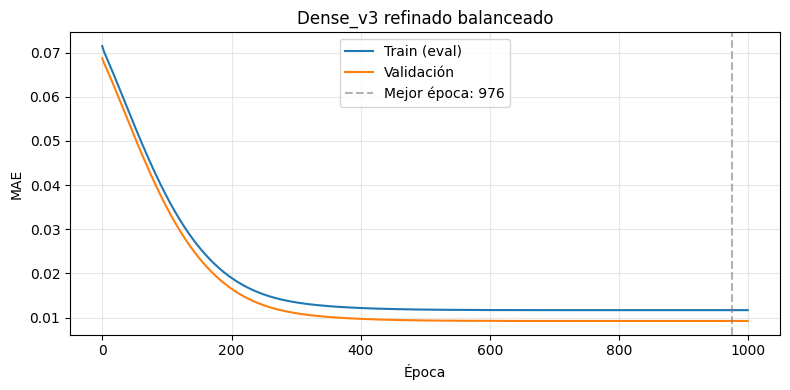

,origen_variable,modelo,mae_train,mae_val,mae_test,gap_train_val,score_convergencia,n_params
0,resultado_dense_3,Dense_v3,0.011158,0.009203,0.012461,0.001955,0.013114,527767
1,resultado_dense_5,Dense_v5,0.011334,0.009450,0.012577,0.001884,0.013217,182807
2,resultado_dense_1,Dense,0.011371,0.009213,0.012348,0.002158,0.013529,212759
3,resultado_dense_6,Dense_v6,0.011507,0.009294,0.012383,0.002213,0.013720,35511
4,resultado_dense_2,Dense_v2,0.011608,0.009215,0.012253,0.002393,0.014001,99543
5,resultado_dense_v3_refinado,Dense_v3_refinado_balanceado,0.011672,0.009218,0.012264,0.002454,0.014126,527767
6,resultado_dense_4,Dense_v4,0.011677,0.009214,0.012260,0.002463,0.014140,98199


resultado_dense elegido por convergencia:
{'modelo': 'Dense_v3', 'mae_train': 0.011158376181378514, 'mae_val': 0.009203191773144026, 'mae_test': 0.01246054125188302, 'n_params': 527767, 'gap_train_val': 0.0019551844082344883, 'funcion': nan, 'best_val_loss': nan, 'best_epoch': nan, 'best_train_eval_loss': nan, 'best_train_val_gap': nan, 'balanced_score': nan}


In [45]:
import numpy as np
import pandas as pd
import keras
import utilidades.modelos as modelos_mod
import utilidades.modelos as modelos_mod
from utilidades.modelos import plot_best_history

# Refinamiento especifico de Dense_v3 buscando curvas mas convergentes.
# Dense_v3 original ganaba por mae_val, pero su mejor epoca era muy temprana.
# Aqui entrenamos mas lento y elegimos penalizando el gap train/validacion.

def construir_dense_v3_param(
    dim_entrada,
    dim_salida,
    units=(384, 192, 96, 48),
    dropout=0.20,
    activation='relu',
    l2=5e-5,
):
    reg = keras.regularizers.l2(l2) if l2 and l2 > 0 else None
    modelo = keras.Sequential(name='Dense_v3_param')
    for i, n_units in enumerate(units):
        kwargs = {'activation': activation, 'kernel_regularizer': reg}
        if i == 0:
            kwargs['input_shape'] = (dim_entrada,)
        modelo.add(keras.layers.Dense(n_units, **kwargs))
        if dropout and dropout > 0:
            modelo.add(keras.layers.Dropout(dropout))
    modelo.add(keras.layers.Dense(dim_salida))
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5), loss='mae')
    return modelo

# Registro solo en memoria para este notebook.
modelos_mod.construir_dense_v3_param = construir_dense_v3_param
modelos_mod.construir_dense_v3_param = construir_dense_v3_param
modelos_mod.construir_dense_v3_param = construir_dense_v3_param

candidatos_dense_v3 = [
    {'nombre': 'Dense_v3_lenta_reg', 'units': (384, 192, 96, 48), 'dropout': 0.20, 'l2': 5e-5, 'lr': 1e-5, 'batch_size': 256, 'epochs': 900},
    {'nombre': 'Dense_v3_lenta_mas_reg', 'units': (384, 192, 96, 48), 'dropout': 0.25, 'l2': 1e-4, 'lr': 1e-5, 'batch_size': 256, 'epochs': 900},
    {'nombre': 'Dense_v3_muy_lenta', 'units': (512, 256, 128, 64), 'dropout': 0.20, 'l2': 5e-5, 'lr': 5e-6, 'batch_size': 256, 'epochs': 1000},
    {'nombre': 'Dense_v3_compacta_suave', 'units': (256, 128, 64, 32), 'dropout': 0.15, 'l2': 5e-5, 'lr': 1e-5, 'batch_size': 256, 'epochs': 900},
]

resultados_dense_v3_refinados = []
historias_dense_v3_refinadas = {}
modelos_dense_v3_refinados = {}

for candidato in candidatos_dense_v3:
    nombre = candidato['nombre']
    cfg = {
        **candidato,
        'factor': 0.85,
        'rlr_patience': 80,
        'min_delta': 1e-8,
        'min_lr': 1e-7,
        'es_patience': 220,
        'restore_best_weights': True,
        'seed': 42,
        'clipnorm': 1.0,
        'verbose': 0,
        'track_train_eval': True,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': 3e-4,
        'gap_weight': 4.0,
        'gap_excess_weight': 18.0,
    }
    cfg.pop('nombre')

    print(f'Entrenando {nombre}...')
    score, best_val, best_epoch, best_train, best_gap, hist, model = modelos_mod._train_one(
        'construir_dense_v3_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(
        model,
        X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=nombre,
    )
    met.update({
        'funcion': 'construir_dense_v3_param',
        'gap_train_val': abs(met['mae_train'] - met['mae_val']),
        'best_val_loss': best_val,
        'best_epoch': best_epoch,
        'best_train_eval_loss': best_train,
        'best_train_val_gap': best_gap,
        'balanced_score': score,
        'cfg': cfg,
    })
    met['score_convergencia'] = (
        met['mae_val']
        + 2.0 * met['gap_train_val']
        + 0.5 * met['best_train_val_gap']
        + (0.001 if best_epoch < int(cfg['epochs'] * 0.35) else 0.0)
    )

    resultados_dense_v3_refinados.append(met)
    historias_dense_v3_refinadas[nombre] = hist
    modelos_dense_v3_refinados[nombre] = model


df_dense_v3_refinados = pd.DataFrame(resultados_dense_v3_refinados).sort_values(
    ['score_convergencia', 'gap_train_val', 'mae_val', 'mae_test']
).reset_index(drop=True)

display(df_dense_v3_refinados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'best_train_val_gap', 'best_epoch',
    'score_convergencia', 'n_params'
]])

mejor_dense_v3_refinado = df_dense_v3_refinados.loc[0, 'modelo']
modelo_dense_v3_refinado = modelos_dense_v3_refinados[mejor_dense_v3_refinado]
hist_dense_v3_refinado = historias_dense_v3_refinadas[mejor_dense_v3_refinado]
resultado_dense_v3_refinado = df_dense_v3_refinados.loc[0].drop(labels=['cfg', 'score_convergencia']).to_dict()
resultado_dense_v3_refinado['modelo'] = 'Dense_v3_refinado_balanceado'

print('Mejor Dense_v3 refinado:', mejor_dense_v3_refinado)
print('Configuracion elegida:', df_dense_v3_refinados.loc[0, 'cfg'])
print(resultado_dense_v3_refinado)
plot_best_history(hist_dense_v3_refinado, 'Dense_v3 refinado balanceado')

# Seleccion final: se incluye el refinado solo si mejora la convergencia sin degradar mucho mae_val.
candidatos_dense_final = []
for nombre_var in [
    'resultado_dense_1', 'resultado_dense_2', 'resultado_dense_3',
    'resultado_dense_4', 'resultado_dense_5', 'resultado_dense_6',
    'resultado_dense_v3_refinado',
]:
    if nombre_var in globals():
        candidato = globals()[nombre_var].copy()
        candidato['origen_variable'] = nombre_var
        candidato['gap_train_val'] = abs(candidato['mae_train'] - candidato['mae_val'])
        candidatos_dense_final.append(candidato)

df_resultados_dense_final = pd.DataFrame(candidatos_dense_final)
df_resultados_dense_final['score_convergencia'] = (
    df_resultados_dense_final['mae_val'] + 2.0 * df_resultados_dense_final['gap_train_val']
)
df_resultados_dense_final = df_resultados_dense_final.sort_values(
    ['score_convergencia', 'gap_train_val', 'mae_val', 'mae_test']
).reset_index(drop=True)

display(df_resultados_dense_final[[
    'origen_variable', 'modelo', 'mae_train', 'mae_val',
    'mae_test', 'gap_train_val', 'score_convergencia', 'n_params'
]])

resultado_dense = df_resultados_dense_final.loc[0].drop(labels=['origen_variable', 'score_convergencia']).to_dict()
if resultado_dense['modelo'] == 'Dense_v3_refinado_balanceado':
    modelo_dense = modelo_dense_v3_refinado
    hist_dense = hist_dense_v3_refinado
else:
    modelo_dense = modelos_dense[resultado_dense['modelo']]
    hist_dense = historias_dense[resultado_dense['modelo']]

resultado_dense['modelo'] = 'Dense'

print('resultado_dense elegido por convergencia:')
print(resultado_dense)


## 1.4 Modelo Recurrente (LSTM)

In [48]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0119 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0118 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 5/100
210/216 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0118
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0117 - val_loss: 0.

{'modelo': 'LSTM', 'mae_train': 0.011655433406509732, 'mae_val': 0.009232556513701383, 'mae_test': 0.012272967913087659, 'n_params': 24023}


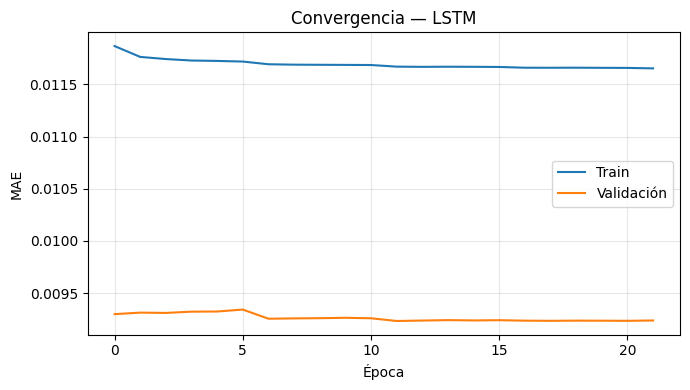

In [29]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)


## 1.4.1 Refinamiento LSTM balanceado


In [ ]:
import numpy as np
import pandas as pd
import keras
import utilidades.modelos as modelos_mod

# Refinamiento de LSTM para que train y validacion converjan sin cruzarse.
# No modifica el LSTM bruto ni funciones compartidas.

def construir_lstm_param(
    forma_entrada,
    dim_salida,
    units=64,
    head_units=32,
    dropout=0.10,
    l2=1e-5,
):
    reg = keras.regularizers.l2(l2) if l2 and l2 > 0 else None
    modelo = keras.Sequential(name='LSTM_param')
    modelo.add(keras.layers.LSTM(
        units=units,
        input_shape=forma_entrada,
        dropout=dropout,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
        bias_regularizer=reg,
        return_sequences=False,
    ))
    modelo.add(keras.layers.Dense(head_units, activation='relu', kernel_regularizer=reg))
    modelo.add(keras.layers.Dense(dim_salida))
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5, clipnorm=0.75), loss='mae')
    return modelo

class TrainEvalLoss(keras.callbacks.Callback):
    def __init__(self, X, y, batch_size=128, n_samples=4096):
        super().__init__()
        self.X = X[-n_samples:] if n_samples and len(X) > n_samples else X
        self.y = y[-n_samples:] if n_samples and len(y) > n_samples else y
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = self.model.evaluate(
            self.X, self.y, batch_size=self.batch_size, verbose=0
        )
        logs['train_eval_loss'] = float(value)


def lr_suave(epoch, lr_base=1.2e-4):
    # Calentamiento para evitar caida vertical.
    if epoch < 70:
        return 8e-6 + (lr_base - 8e-6) * (epoch + 1) / 70
    # Descenso controlado.
    if epoch < 360:
        t = (epoch - 70) / 290
        return 1.8e-5 + (lr_base - 1.8e-5) * (1 - t) ** 2
    # Ajuste fino.
    return 7e-6

candidatos_lstm_refinados = [
    {'nombre': 'LSTM_64_do10_l2', 'units': 64, 'head_units': 32, 'dropout': 0.10, 'l2': 1e-5, 'lr_base': 1.2e-4},
    {'nombre': 'LSTM_64_do15_l2', 'units': 64, 'head_units': 32, 'dropout': 0.15, 'l2': 2e-5, 'lr_base': 1.2e-4},
    {'nombre': 'LSTM_48_do10_l2', 'units': 48, 'head_units': 32, 'dropout': 0.10, 'l2': 1e-5, 'lr_base': 1.5e-4},
    {'nombre': 'LSTM_80_do15_l2', 'units': 80, 'head_units': 32, 'dropout': 0.15, 'l2': 2e-5, 'lr_base': 1.0e-4},
]

EPOCHS_LSTM = 650
BATCH_LSTM = 128

resultados_lstm_refinados = []
historias_lstm_refinadas = {}
modelos_lstm_refinados = {}

for candidato in candidatos_lstm_refinados:
    nombre = candidato['nombre']
    keras.backend.clear_session()
    keras.utils.set_random_seed(42)

    model = construir_lstm_param(
        X_train.shape[1:], y_train.shape[1],
        units=candidato['units'],
        head_units=candidato['head_units'],
        dropout=candidato['dropout'],
        l2=candidato['l2'],
    )

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_LSTM,
        batch_size=BATCH_LSTM,
        callbacks=[
            TrainEvalLoss(X_train, y_train, batch_size=BATCH_LSTM, n_samples=4096),
            keras.callbacks.LearningRateScheduler(
                lambda epoch, lr=None: lr_suave(epoch, candidato['lr_base']), verbose=0
            ),
        ],
        verbose=0,
    )

    train_curve = np.array(hist.history['train_eval_loss'])
    val_curve = np.array(hist.history['val_loss'])
    signed_gap = train_curve - val_curve
    gap_curve = np.abs(signed_gap)
    cross_curve = np.maximum(0.0, -signed_gap)  # penaliza train por debajo de validacion
    pendiente = np.abs(np.gradient(val_curve))

    # Elegimos una epoca tardia, estable, con curvas cercanas pero sin cruce.
    inicio_zona_plana = int(EPOCHS_LSTM * 0.50)
    score_curve = (
        0.20 * val_curve
        + 3.0 * gap_curve
        + 10.0 * cross_curve
        + 10.0 * pendiente
    )
    best_idx = inicio_zona_plana + int(np.argmin(score_curve[inicio_zona_plana:]))

    met = evaluar_modelo(model, X_train, y_train, X_val, y_val, X_test, y_test, nombre=nombre)
    met.update({
        'gap_train_val': abs(met['mae_train'] - met['mae_val']),
        'gap_train_test': abs(met['mae_train'] - met['mae_test']),
        'best_val_loss': float(val_curve[best_idx]),
        'best_epoch': best_idx + 1,
        'best_train_eval_loss': float(train_curve[best_idx]),
        'best_train_val_gap': float(gap_curve[best_idx]),
        'best_signed_gap': float(signed_gap[best_idx]),
        'best_cross_penalty': float(cross_curve[best_idx]),
        'score_convergencia': float(score_curve[best_idx]),
        'cfg': candidato,
    })

    resultados_lstm_refinados.append(met)
    historias_lstm_refinadas[nombre] = hist
    modelos_lstm_refinados[nombre] = model


df_lstm_refinados = pd.DataFrame(resultados_lstm_refinados).sort_values(
    ['best_cross_penalty', 'best_train_val_gap', 'gap_train_val', 'score_convergencia']
).reset_index(drop=True)

display(df_lstm_refinados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap',
    'best_signed_gap', 'best_cross_penalty', 'best_epoch', 'n_params'
]])

mejor_lstm_refinado = df_lstm_refinados.loc[0, 'modelo']
modelo_lstm_refinado = modelos_lstm_refinados[mejor_lstm_refinado]
hist_lstm_refinado = historias_lstm_refinadas[mejor_lstm_refinado]
resultado_lstm_refinado = df_lstm_refinados.loc[0].drop(labels=['cfg', 'score_convergencia']).to_dict()
resultado_lstm_refinado['modelo'] = 'LSTM_param_refinado_balanceado'

historia = hist_lstm_refinado.history
train_curve = np.array(historia['train_eval_loss'])
val_curve = np.array(historia['val_loss'])
best_epoch = int(resultado_lstm_refinado['best_epoch'])

plt.figure(figsize=(8, 4))
plt.plot(train_curve, label='Train (eval)')
plt.plot(val_curve, label='Validacion')
plt.axvline(best_epoch - 1, color='gray', ls='--', alpha=0.7, label=f'Mejor epoca: {best_epoch}')
plt.title('LSTM refinado balanceado')
plt.xlabel('Epoca')
plt.ylabel('MAE')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Mejor LSTM refinado:', mejor_lstm_refinado)
print('Configuracion elegida:', df_lstm_refinados.loc[0, 'cfg'])
print(resultado_lstm_refinado)

# Si esta curva mejora la del LSTM bruto, puedes usar este resultado en competicion:
# resultado_lstm = resultado_lstm_refinado


## 1.5 Modelo Conv1D

In [30]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 28, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 28, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,415 (44.59 KB)

 Trainable params: 11,415 (44.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 5/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - val_loss: 0.0

{'modelo': 'Conv1D', 'mae_train': 0.011660772421165269, 'mae_val': 0.009211985048363958, 'mae_test': 0.01225621772771195, 'n_params': 11415}


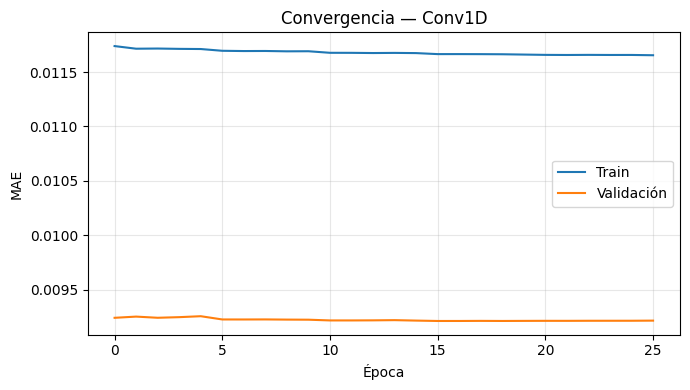

In [31]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)


### 1.5.1 Refinamiento Conv1D balanceado


Entrenando Conv1D_48_lr5e6_do05...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando Conv1D_64_lr5e6_do05...
Entrenando Conv1D_48_lr3e6_do00...


,modelo,mae_train,mae_val,mae_test,gap_train_val,gap_train_test,best_train_val_gap,best_epoch,n_params
0,Conv1D_48_lr5e6_do05,0.011669,0.009218,0.012262,0.002451,0.000593,0.002451,1196,7415
1,Conv1D_64_lr5e6_do05,0.011665,0.009214,0.012259,0.002452,0.000594,0.002452,1199,11415
2,Conv1D_48_lr3e6_do00,0.011670,0.009218,0.012262,0.002452,0.000592,0.002452,1199,7415


Mejor Conv1D refinado: Conv1D_48_lr5e6_do05
{'modelo': 'Conv1D_param_refinado_balanceado', 'mae_train': 0.011669309383872825, 'mae_val': 0.009218187987168912, 'mae_test': 0.012262318885523645, 'n_params': 7415, 'gap_train_val': 0.0024511213967039133, 'gap_train_test': 0.0005930095016508201, 'best_train_val_gap': 0.0024511199444532394, 'best_epoch': 1196, 'balanced_score': 0.072702906280756}


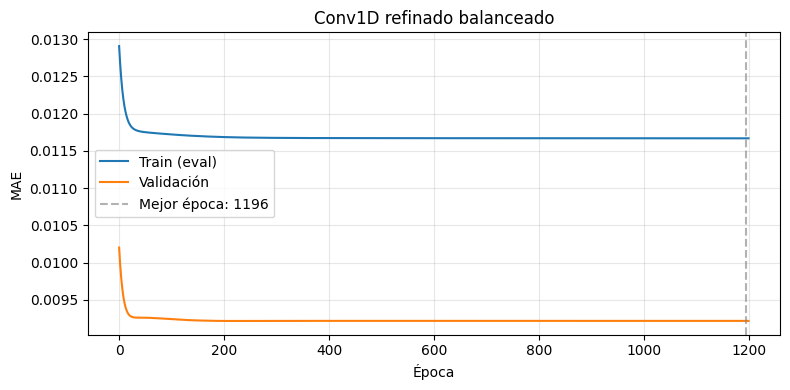

In [51]:
import numpy as np
import pandas as pd
import keras
import utilidades.modelos as modelos_mod
import utilidades.modelos as modelos_mod
from utilidades.modelos import plot_best_history

# Refinamiento Conv1D balanceado.
# Mantenemos el mismo flujo y solo ajustamos parametros para suavizar la curva:
# lr bajo, batch grande, mas epocas y poca regularizacion porque train > validacion.

def construir_conv1d_param(forma_entrada, dim_salida, filtros=48, dropout=0.05, l2=0.0, kernel_size=3):
    reg = modelos_mod.regularizers.l2(l2) if l2 else None
    modelo = modelos_mod.Sequential(name='Conv1D_param')
    modelo.add(modelos_mod.Conv1D(
        filtros, kernel_size=kernel_size, activation='relu', padding='same',
        kernel_regularizer=reg, input_shape=forma_entrada,
    ))
    modelo.add(modelos_mod.Conv1D(
        max(8, filtros // 2), kernel_size=kernel_size, activation='relu', padding='same',
        kernel_regularizer=reg,
    ))
    modelo.add(modelos_mod.GlobalAveragePooling1D())
    if dropout > 0:
        modelo.add(modelos_mod.Dropout(dropout))
    modelo.add(modelos_mod.Dense(dim_salida, kernel_regularizer=reg))
    modelo.compile(optimizer='adam', loss='mae')
    return modelo

modelos_mod.construir_conv1d_param = construir_conv1d_param
modelos_mod.construir_conv1d_param = construir_conv1d_param

candidatos_conv = [
    {'nombre': 'Conv1D_48_lr5e6_do05', 'filtros': 48, 'dropout': 0.05, 'l2': 0.0,  'lr': 5e-6},
    {'nombre': 'Conv1D_64_lr5e6_do05', 'filtros': 64, 'dropout': 0.05, 'l2': 0.0,  'lr': 5e-6},
    {'nombre': 'Conv1D_48_lr3e6_do00', 'filtros': 48, 'dropout': 0.00, 'l2': 0.0,  'lr': 3e-6},
]

resultados_conv_balanceados = []
historias_conv_balanceadas = {}
modelos_conv_balanceados = {}

for candidato in candidatos_conv:
    nombre = candidato['nombre']
    cfg = {
        **candidato,
        'epochs': 1200,
        'batch_size': 512,
        'factor': 0.90,
        'rlr_patience': 120,
        'min_delta': 1e-8,
        'min_lr': 5e-7,
        'es_patience': 300,
        'restore_best_weights': True,
        'seed': 42,
        'clipnorm': 0.25,
        'verbose': 0,
        'track_train_eval': True,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': 5e-4,
        'gap_weight': 6.0,
        'gap_excess_weight': 25.0,
    }
    cfg.pop('nombre')

    print(f'Entrenando {nombre}...')
    score, best_val, best_epoch, best_train, best_gap, hist, model = modelos_mod._train_one(
        'construir_conv1d_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(model, X_train, y_train, X_val, y_val, X_test, y_test, nombre=nombre)
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['balanced_score'] = score

    resultados_conv_balanceados.append(met)
    historias_conv_balanceadas[nombre] = hist
    modelos_conv_balanceados[nombre] = model


df_conv_balanceados = pd.DataFrame(resultados_conv_balanceados).sort_values(
    ['gap_train_val', 'best_train_val_gap', 'mae_val', 'mae_test']
).reset_index(drop=True)

display(df_conv_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap', 'best_epoch', 'n_params'
]])

mejor_conv = df_conv_balanceados.loc[0, 'modelo']
modelo_conv_balanceado = modelos_conv_balanceados[mejor_conv]
hist_conv_balanceado = historias_conv_balanceadas[mejor_conv]
resultado_conv_balanceado = df_conv_balanceados.loc[0].to_dict()
resultado_conv_balanceado['modelo'] = 'Conv1D_param_refinado_balanceado'

print('Mejor Conv1D refinado:', mejor_conv)
print(resultado_conv_balanceado)
plot_best_history(hist_conv_balanceado, 'Conv1D refinado balanceado')


## 1.6 Modelo Mixto (Conv1D + LSTM)

In [33]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


Model: "Mixto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,999 (152.34 KB)

 Trainable params: 38,999 (152.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0118 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 5/100
213/216 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0117
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0093 - learning_rate: 5.0000e-04
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0117 - val_loss: 0.0

{'modelo': 'Mixto', 'mae_train': 0.011729691226957236, 'mae_val': 0.009273322931616848, 'mae_test': 0.012312008540892868, 'n_params': 38999}


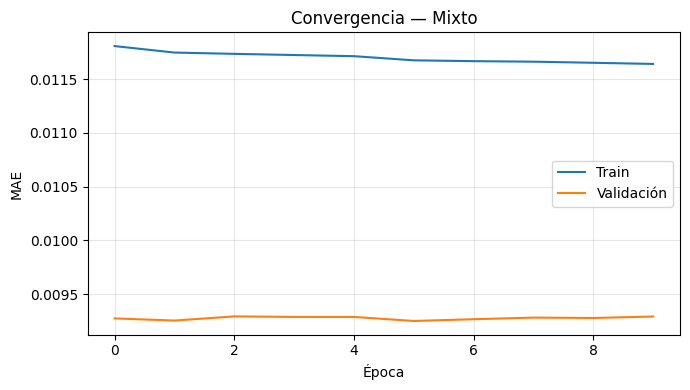

In [34]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

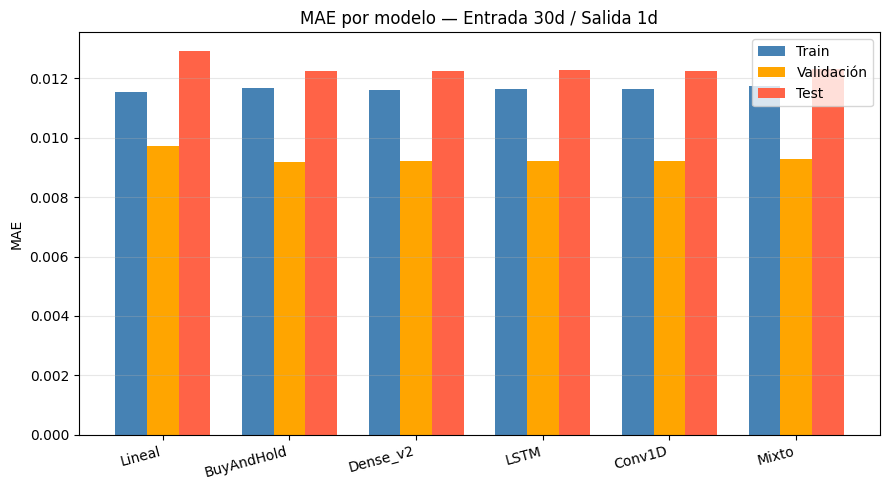

Resultados [competicion] guardados en: ../resultados/metricas/ent30_sal01.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.011530,0.009722,0.012909,0
BuyAndHold,0.011694,0.009199,0.012251,0
Dense_v2,0.011608,0.009215,0.012253,99543
LSTM,0.011655,0.009233,0.012273,24023
Conv1D,0.011661,0.009212,0.012256,11415
Mixto,0.011730,0.009273,0.012312,38999


In [35]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [36]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


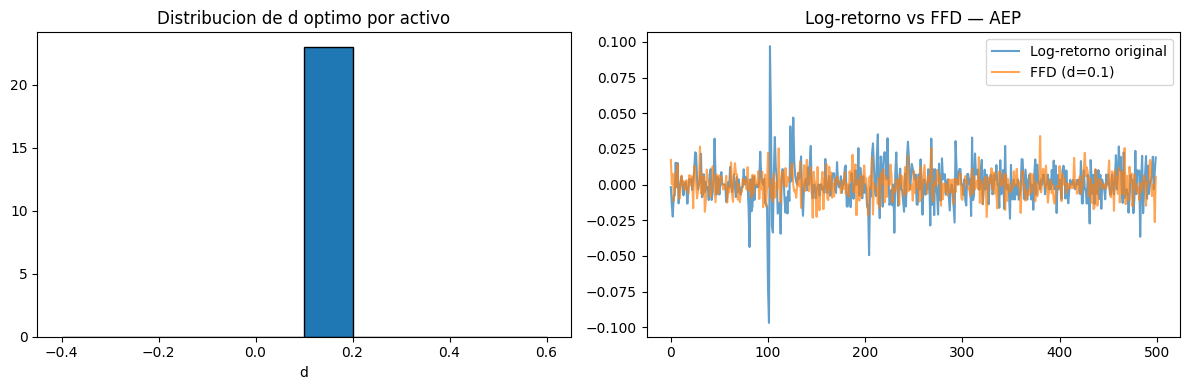

In [37]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [38]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


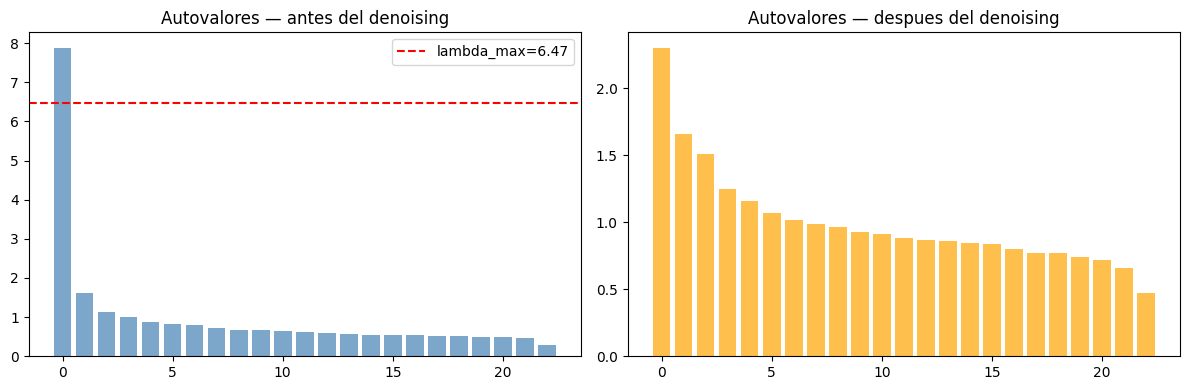

In [39]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [40]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (13389, 30, 23)  Val: (705, 30, 23)  Test: (1567, 30, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Conv1D
Epoch 1/100


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6951 - val_loss: 0.5714 - learning_rate: 0.0010
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6937 - val_loss: 0.5714 - learning_rate: 0.0010
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6935 - val_loss: 0.5714 - learning_rate: 0.0010
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6933 - val_loss: 0.5715 - learning_rate: 0.0010
Epoch 5/100
197/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6983
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6931 - val_loss: 0.5713 - learning_rate: 0.0010
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6927 - val_loss: 0.5713 - learning_rate: 5.0000e-04
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6926 - val_loss: 0.5712 - learning_rate: 5.0000e-04
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6923 - val_loss: 0.5712 - learni

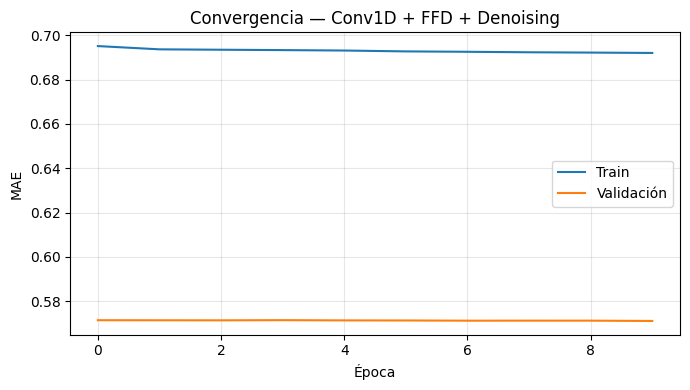

In [41]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Conv1D,0.011661,0.009212,0.012256,11415
Conv1D_prep,0.693528,0.571430,0.715676,11415


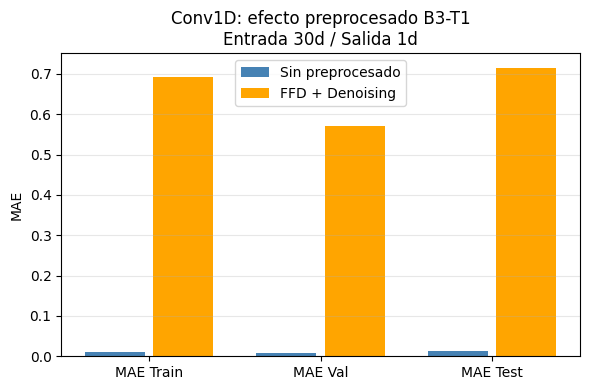

Variacion MAE test con preprocesado: -5739.3%
Resultados [investigacion] guardados en: ../resultados/metricas/ent30_sal01.json


In [42]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
